# **Import Libraries**

In [196]:
import os
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# **Load Data**

In [197]:
# Download dataset
path = kagglehub.dataset_download("arashnic/hr-ana")

print("Dataset path:", path)

Using Colab cache for faster access to the 'hr-ana' dataset.
Dataset path: /kaggle/input/hr-ana


In [198]:
df_train = pd.read_csv(f"{path}/train.csv")
df_test = pd.read_csv(f"{path}/test.csv")

# **Data Exploration & Data Quality Check**

#### **Top Rows**

In [199]:
df_train.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,73,0


In [200]:
df_test.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
0,8724,Technology,region_26,Bachelor's,m,sourcing,1,24,NaN,1,0,77
1,74430,HR,region_4,Bachelor's,f,other,1,31,3.0,5,0,51
2,72255,Sales & Marketing,region_13,Bachelor's,m,other,1,31,1.0,4,0,47
3,38562,Procurement,region_2,Bachelor's,f,other,3,31,2.0,9,0,65
4,64486,Finance,region_29,Bachelor's,m,sourcing,1,30,4.0,7,0,61


#### **Last Rows**

In [201]:
df_train.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,45,0
54807,51526,HR,region_22,Bachelor's,m,other,1,27,1.0,5,0,49,0


In [202]:
df_test.tail()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
23485,53478,Legal,region_2,Below Secondary,m,sourcing,1,24,3.0,1,0,61
23486,25600,Technology,region_25,Bachelor's,m,sourcing,1,31,3.0,7,0,74
23487,45409,HR,region_16,Bachelor's,f,sourcing,1,26,4.0,4,0,50
23488,1186,Procurement,region_31,Bachelor's,m,sourcing,3,27,NaN,1,0,70
23489,5973,Technology,region_17,Master's & above,m,other,3,40,5.0,5,0,89


#### **Data Dimensions**

In [203]:
print(f'Shape of Train Data: {df_train.shape}')

Shape of Train Data: (54808, 13)


In [204]:
print(f'Shape of Test Data: {df_test.shape}')

Shape of Test Data: (23490, 12)


#### **Information about Dataset**

In [205]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


In [206]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23490 entries, 0 to 23489
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           23490 non-null  int64  
 1   department            23490 non-null  object 
 2   region                23490 non-null  object 
 3   education             22456 non-null  object 
 4   gender                23490 non-null  object 
 5   recruitment_channel   23490 non-null  object 
 6   no_of_trainings       23490 non-null  int64  
 7   age                   23490 non-null  int64  
 8   previous_year_rating  21678 non-null  float64
 9   length_of_service     23490 non-null  int64  
 10  awards_won?           23490 non-null  int64  
 11  avg_training_score    23490 non-null  int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 2.2+ MB


#### **Statistical Summary**

**Numerical Columns**

In [207]:
print("Statistical Summary of Numerical Columns for Train Data:\n")
df_train.describe()

Statistical Summary of Numerical Columns for Train Data:



,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


**Observations on Training dataset:**

- **Count:** There are 54,808 observations in the training dataset.

- **no_of_trainings:** On average, employees have undergone around 1.25 training sessions, with a minimum of 1 and a maximum of 10.

- **age:** The average age of employees is approximately 34.80 years, with a minimum age of 20 and a maximum age of 60.

- **previous_year_rating:** The average rating from the previous year is 3.33, with a minimum rating of 1 and a maximum rating of 5.

- **length_of_service:** The average length of service is approximately 5.87 years, with a minimum of 1 year and a maximum of 37 years.

- **awards_won?:** A small percentage of employees (2.32%) have won awards (values are 0 or 1).

- **avg_training_score:** The average training score is around 63.39, with a minimum score of 39 and a maximum score of 99.

- **is_promoted:** Approximately 8.52% of employees have been promoted (values are 0 or 1).

In [208]:
print("Statistical Summary of Numerical Columns for Test Data:\n")
df_test.describe()

Statistical Summary of Numerical Columns for Test Data:



,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
count,23490.000000,23490.000000,23490.000000,21678.000000,23490.000000,23490.000000,23490.000000
mean,39041.399149,1.254236,34.782929,3.339146,5.810387,0.022776,63.263133
std,22640.809201,0.600910,7.679492,1.263294,4.207917,0.149191,13.411750
min,3.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000
25%,19370.250000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000
50%,38963.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000
75%,58690.000000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000
max,78295.000000,9.000000,60.000000,5.000000,34.000000,1.000000,99.000000


**Observations on Training dataset:**

- **Count:** There are 23,490 observations in the testing dataset.

- **no_of_trainings:** On average, employees have undergone around 1.25 training sessions, with a minimum of 1 and a maximum of 9.

- **age:** The average age of employees is approximately 34.78 years, with a minimum age of 20 and a maximum age of 60.

- **previous_year_rating:** The average rating from the previous year is 3.34, with a minimum rating of 1 and a maximum rating of 5.

- **length_of_service:** The average length of service is approximately 5.81 years, with a minimum of 1 year and a maximum of 34 years.

- **awards_won?:** A small percentage of employees (2.28%) have won awards (values are 0 or 1).

- **avg_training_score:** The average training score is around 63.26, with a minimum score of 39 and a maximum score of 99.

**Overall Observations:**
The two datasets are similar in terms of the variables they contain.
Both datasets show comparable average values for important variables such as age, previous_year_rating, length_of_service, awards_won?, and average_training_score. However, the maximum length_of_service is slightly higher in the training dataset (37 years) compared to the testing dataset (34 years).

The dataset is split into approximately 70% training data (54,808 out of 78,298 records) and 30% testing data (23,490 out of 78,298 records).

**Categorical Columns**

In [209]:
print("Statistical Summary of Categorical Columns for Train Data:\n")
df_train.describe(include='object')

Statistical Summary of Categorical Columns for Train Data:



,department,region,education,gender,recruitment_channel
count,54808,54808,52399,54808,54808
unique,9,34,3,2,3
top,Sales & Marketing,region_2,Bachelor's,m,other
freq,16840,12343,36669,38496,30446


In [210]:
print("Statistical Summary of Categorical Columns for Test Data:\n")
df_test.describe(include='object')

Statistical Summary of Categorical Columns for Test Data:



,department,region,education,gender,recruitment_channel
count,23490,23490,22456,23490,23490
unique,9,34,3,2,3
top,Sales & Marketing,region_2,Bachelor's,m,other
freq,7315,5299,15578,16596,13078


It is important to ensure that the test dataset is representative of the training dataset to develop a reliable predictive model. Identifying similarities and differences between both datasets helps in appropriate data preprocessing and improves the effectiveness of model training and evaluation.

#### **Unique Values Column-wise**

**Observations:**
After reviewing both the training and testing datasets, the following patterns were observed:

Both datasets show similar distributions for no_of_trainings. However, the training set includes a maximum of 10 trainings, while the test set goes up to 9 trainings. Overall, both datasets follow a similar pattern.
Both datasets also have similar length_of_service values, ranging from 1 to 30+ years. The maximum value is slightly higher in the training set (37 years) compared to the test set (34 years). Overall, both datasets remain consistent in distribution.

**Unique Values for Train Dataset**

In [211]:
print("Unique Values for Train Data")
df_train.nunique()

Unique Values for Train Data


,0
employee_id,54808
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,10
age,41
previous_year_rating,5
length_of_service,35


In [212]:
df_train['department'].unique()

array(['Sales & Marketing', 'Operations', 'Technology', 'Analytics',
       'R&D', 'Procurement', 'Finance', 'HR', 'Legal'], dtype=object)

In [213]:
df_train['education'].unique()

array(["Master's & above", "Bachelor's", nan, 'Below Secondary'],
      dtype=object)

In [214]:
df_train['recruitment_channel'].unique()

array(['sourcing', 'other', 'referred'], dtype=object)

In [215]:
df_train['previous_year_rating'].unique()

array([ 5.,  3.,  1.,  4., nan,  2.])

In [216]:
df_train['no_of_trainings'].unique()

array([ 1,  2,  3,  4,  7,  5,  6,  8, 10,  9])

In [217]:
df_train['length_of_service'].unique()

array([ 8,  4,  7, 10,  2,  5,  6,  1,  3, 16,  9, 11, 26, 12, 17, 14, 13,
       19, 15, 23, 18, 20, 22, 25, 28, 24, 31, 21, 29, 30, 34, 27, 33, 32,
       37])

**Unique Values for Test Dataset**

In [218]:
print("Unique Values for Train Data")
df_test.nunique()

Unique Values for Train Data


,0
employee_id,23490
department,9
region,34
education,3
gender,2
recruitment_channel,3
no_of_trainings,9
age,41
previous_year_rating,5
length_of_service,34


In [219]:
df_test['education'].unique()

array(["Bachelor's", "Master's & above", nan, 'Below Secondary'],
      dtype=object)

In [220]:
df_test['no_of_trainings'].unique()

array([1, 3, 2, 4, 5, 7, 6, 8, 9])

In [221]:
df_test['length_of_service'].unique()

array([ 1,  5,  4,  9,  7,  2,  3, 11, 12, 10,  6, 14, 18,  8, 26, 13, 22,
       19, 21, 15, 16, 17, 23, 20, 31, 24, 27, 28, 25, 29, 33, 30, 34, 32])

#### **Unique Count Column-wise**

In [222]:
print('Values Count per Column:\n')

for col in df_train.columns:
  print(f'{df_train[col].value_counts()}')
  print('-------------------------------------')

Values Count per Column:

employee_id
51526    1
65438    1
65141    1
7513     1
2542     1
        ..
60051    1
49017    1
29934    1
28911    1
73202    1
Name: count, Length: 54808, dtype: int64
-------------------------------------
department
Sales & Marketing    16840
Operations           11348
Technology            7138
Procurement           7138
Analytics             5352
Finance               2536
HR                    2418
Legal                 1039
R&D                    999
Name: count, dtype: int64
-------------------------------------
region
region_2     12343
region_22     6428
region_7      4843
region_15     2808
region_13     2648
region_26     2260
region_31     1935
region_4      1703
region_27     1659
region_16     1465
region_28     1318
region_11     1315
region_23     1175
region_29      994
region_32      945
region_19      874
region_20      850
region_14      827
region_25      819
region_17      796
region_5       766
region_6       690
region_30      657


####**Handling Null Values**

In [223]:
print("Missing Values per Column - Train Data:")
df_train.isnull().sum()

Missing Values per Column - Train Data:


,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [224]:
print("Missing Values per Column - Test Data:")
df_test.isnull().sum()

Missing Values per Column - Test Data:


,0
employee_id,0
department,0
region,0
education,1034
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,1812
length_of_service,0


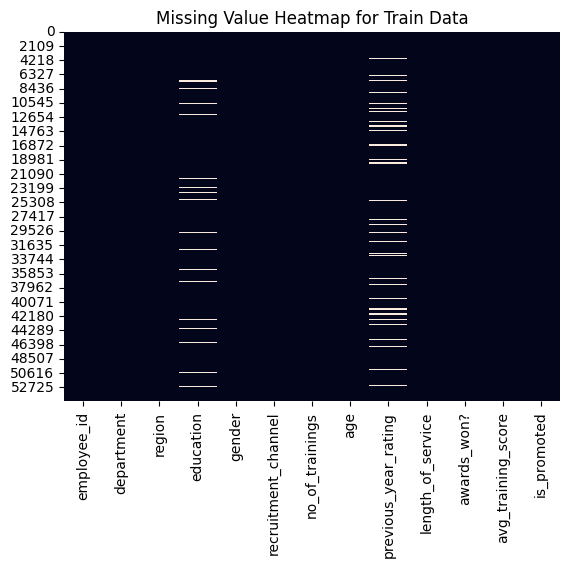

In [225]:
sns.heatmap(df_train.isna(), cbar=False)
plt.title("Missing Value Heatmap for Train Data")
plt.show()

Only two features, **education** and **previous_year_rating**, have missing values in both the train and test datasets. Both are categorical features, but in the train dataset, one has nearly twice as many missing values as the other. Since these missing values may hold useful information, we should not simply drop the rows. Instead, we need to apply an appropriate imputation method to fill them.

In [226]:
print("Train - Education value counts")
df_train['education'].value_counts()

Train - Education value counts


,count
education,
Bachelor's,36669
Master's & above,14925
Below Secondary,805


In [227]:
print("Test - Education value counts")
df_test['education'].value_counts()

Test - Education value counts


,count
education,
Bachelor's,15578
Master's & above,6504
Below Secondary,374


In [228]:
print("------------- TRAIN (%) ---------------")
print((df_train['education'].value_counts(dropna=False, normalize=True) * 100).round(2))

print("\n------------- TEST (%) ---------------")
print((df_test['education'].value_counts(dropna=False, normalize=True) * 100).round(2))

------------- TRAIN (%) ---------------
education
Bachelor's          66.90
Master's & above    27.23
NaN                  4.40
Below Secondary      1.47
Name: proportion, dtype: float64

------------- TEST (%) ---------------
education
Bachelor's          66.32
Master's & above    27.69
NaN                  4.40
Below Secondary      1.59
Name: proportion, dtype: float64


In [229]:
print("------------- TRAIN ---------------")
print(df_train['previous_year_rating'].value_counts())

print("\n------------- TEST ---------------")
print(df_test['previous_year_rating'].value_counts())

------------- TRAIN ---------------
previous_year_rating
3.0    18618
5.0    11741
4.0     9877
1.0     6223
2.0     4225
Name: count, dtype: int64

------------- TEST ---------------
previous_year_rating
3.0    7921
5.0    5097
4.0    4249
1.0    2680
2.0    1731
Name: count, dtype: int64


Missing categorical values were imputed using an **"Unknown"** category to maintain data integrity and capture potential hidden patterns associated with missing information.

In [230]:
df_train['education'] = df_train['education'].fillna('Unknown')
df_test['education'] = df_train['education'].fillna('Unknown')

Missing values in **previous_year_rating** were imputed using the **mode** since the feature follows an ordinal rating scale. Mode imputation preserves the existing distribution while maintaining consistency in employee performance ratings.

In [231]:
df_train['previous_year_rating'] = df_train['previous_year_rating'].fillna(
    df_train['previous_year_rating'].mode()[0]
)

df_test['previous_year_rating'] = df_test['previous_year_rating'].fillna(
    df_test['previous_year_rating'].mode()[0]
)

In [232]:
df_train.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [233]:
df_test.isnull().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [234]:
# Sanity check
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             54808 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  54808 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


The **previous_year_rating** column is stored as a float due to the presence of missing values (NaN) in the dataset. In pandas, numerical columns containing NaN are automatically converted to float type, even if the actual values are integers. After handling the missing values, this feature can be safely converted back to integer type as it represents ordinal ratings **(1–5)**.

In [235]:
df_train['previous_year_rating'] = df_train['previous_year_rating'].astype(int)
df_test['previous_year_rating'] = df_test['previous_year_rating'].astype(int)

In [236]:
df_train.dtypes

,0
employee_id,int64
department,object
region,object
education,object
gender,object
recruitment_channel,object
no_of_trainings,int64
age,int64
previous_year_rating,int64
length_of_service,int64


#### **Handling Duplicates**

In [237]:
duplicate_count = df_train.duplicated().sum()

print("Number of duplicate rows in Train Data:", duplicate_count)

Number of duplicate rows in Train Data: 0


In [238]:
# Remove duplicate records (if any)

duplicate_count = df_test.duplicated().sum()

print("Number of duplicate rows in Test data:", duplicate_count)

Number of duplicate rows in Test data: 0


#### **Removing Identifiers**

The employee_id column was removed from the numerical features list because it is a unique identifier and does not carry any predictive information. Including it in analysis or modeling could introduce noise without adding meaningful value, so it is excluded from further EDA and visualization steps.

In [239]:
numerical_cols_train = df_train.select_dtypes(include=['number']).columns.tolist()
categorical_cols_train = df_train.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns identified for plotting: {numerical_cols_train}")
print(f"Categorical columns identified for plotting: {categorical_cols_train}")

Numerical columns identified for plotting: ['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score', 'is_promoted']
Categorical columns identified for plotting: ['department', 'region', 'education', 'gender', 'recruitment_channel']


In [240]:
numerical_cols_train.remove('employee_id')

In [241]:
numerical_cols_test = df_test.select_dtypes(include=['number']).columns.tolist()
categorical_cols_test = df_test.select_dtypes(include='object').columns.tolist()

print(f"Numerical columns identified for plotting: {numerical_cols_test}")
print(f"Categorical columns identified for plotting: {categorical_cols_test}")

Numerical columns identified for plotting: ['employee_id', 'no_of_trainings', 'age', 'previous_year_rating', 'length_of_service', 'awards_won?', 'avg_training_score']
Categorical columns identified for plotting: ['department', 'region', 'education', 'gender', 'recruitment_channel']


In [242]:
numerical_cols_test.remove('employee_id')

# **Exploratory Data Analysis (EDA)**

### **Univariate Analysis**

In [262]:
df_train['is_promoted'].value_counts(normalize=True) * 100

,proportion
is_promoted,
0,91.482995
1,8.517005


/tmp/ipykernel_2231/2029994099.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_train, x='is_promoted', palette='viridis')
/tmp/ipykernel_2231/2029994099.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Promoted', 'Promoted'])


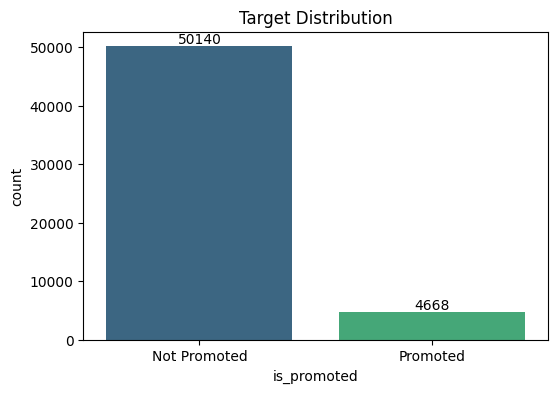

In [243]:
# Target distribution plot
plt.figure(figsize=(6,4))

ax = sns.countplot(data=df_train, x='is_promoted', palette='viridis')

plt.title('Target Distribution')

for container in ax.containers:
    ax.bar_label(container)

ax.set_xticklabels(['Not Promoted', 'Promoted'])

plt.show()

**Observation:** There are significantly fewer positive cases (promotions) compared to negative cases, indicating a class imbalance problem.

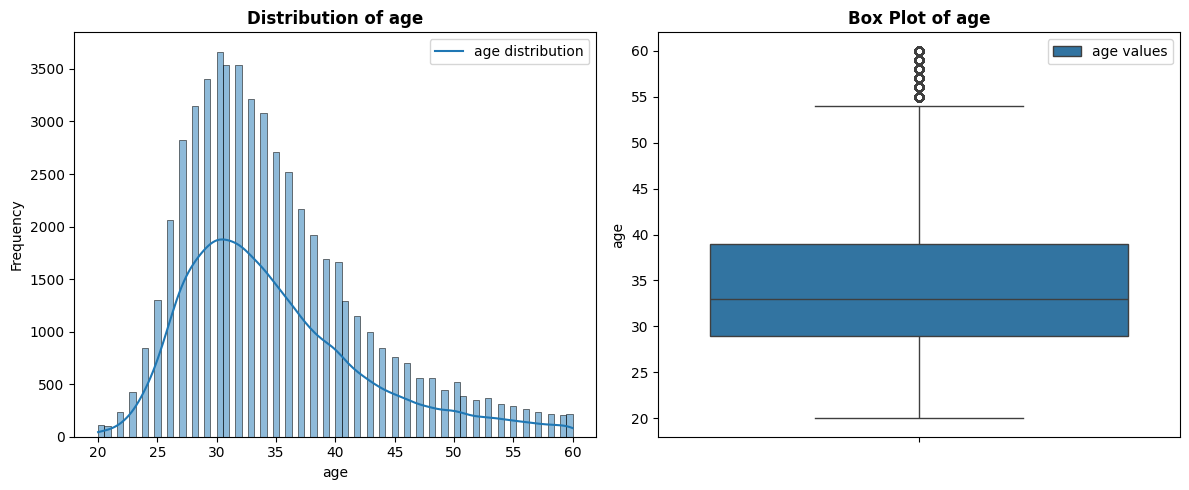

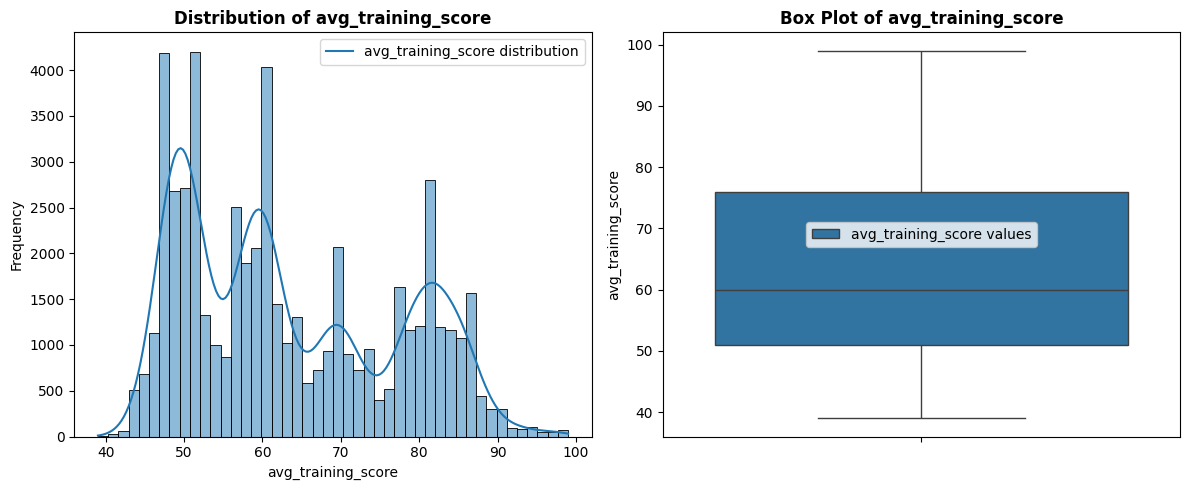

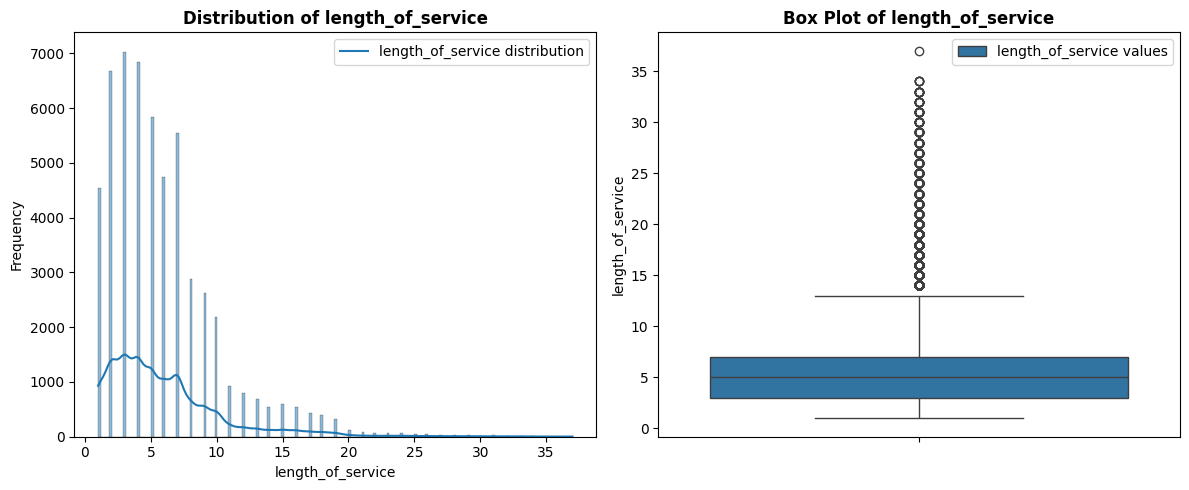

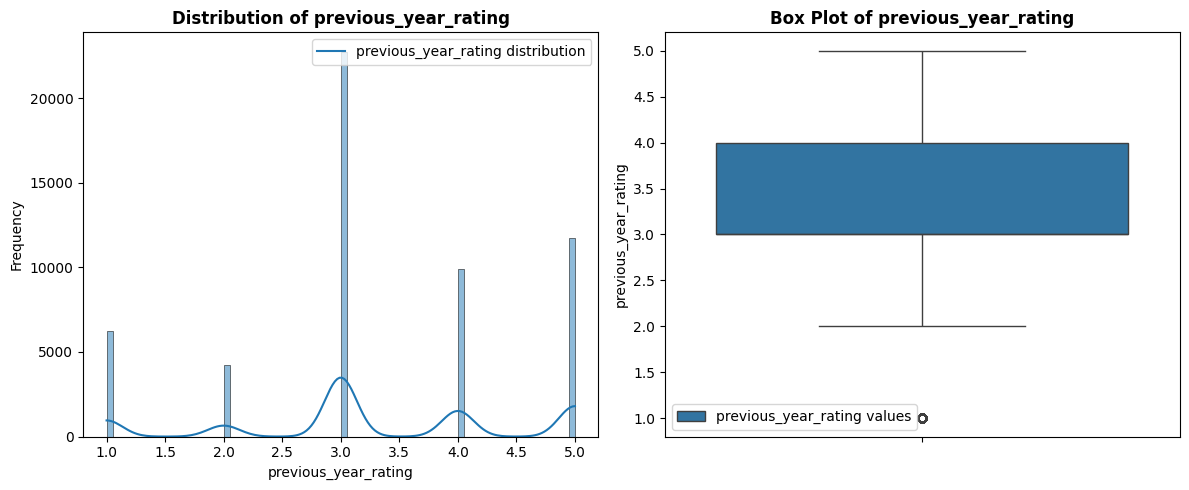

In [244]:
# Plot for numerical columns
numerical_cols_train = ['age','avg_training_score', 'length_of_service', 'previous_year_rating']

for col in numerical_cols_train:
    plt.figure(figsize=(12, 5))

    # Histogram
    plt.subplot(1, 2, 1)
    sns.histplot(df_train[col], kde=True)
    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend([f'{col} distribution'])

    # Box Plot
    plt.subplot(1, 2, 2)
    sns.boxplot(y=df_train[col])
    plt.title(f'Box Plot of {col}', fontweight='bold')
    plt.ylabel(col)
    plt.legend([f'{col} values'])

    plt.tight_layout()
    plt.show()

**Observation:**
- Employees are mostly age between 25-40.
- Training scores are spread across all ranges, but the distribution peaks in the 46–60 interval, suggesting that most employees achieve moderate performance in training rather than very high or very low scores.
- Employees with 2–5 years of service form the largest group in the organization.
- The majority of employees have less than 10 years of experience in the company.
- Very few employees remain beyond 20 years, suggesting limited long-term retention or the workforce is mostly young.
- Ratings of 3.0, 4.0, and 5.0 make up a large portion of employees, indicating that most employees fall within this performance range.

/tmp/ipykernel_2231/456599800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


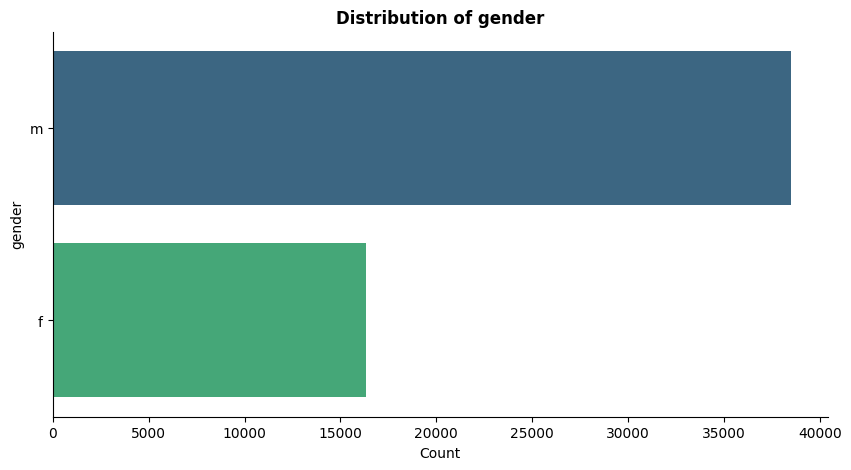

/tmp/ipykernel_2231/456599800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


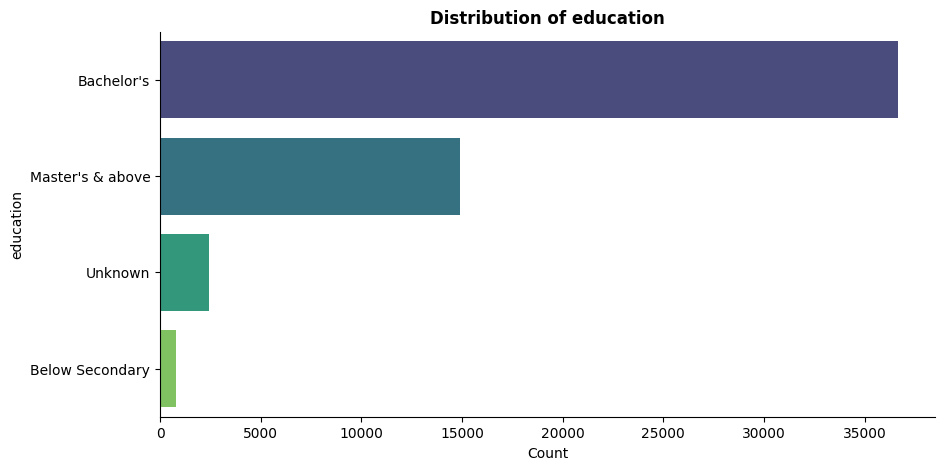

/tmp/ipykernel_2231/456599800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


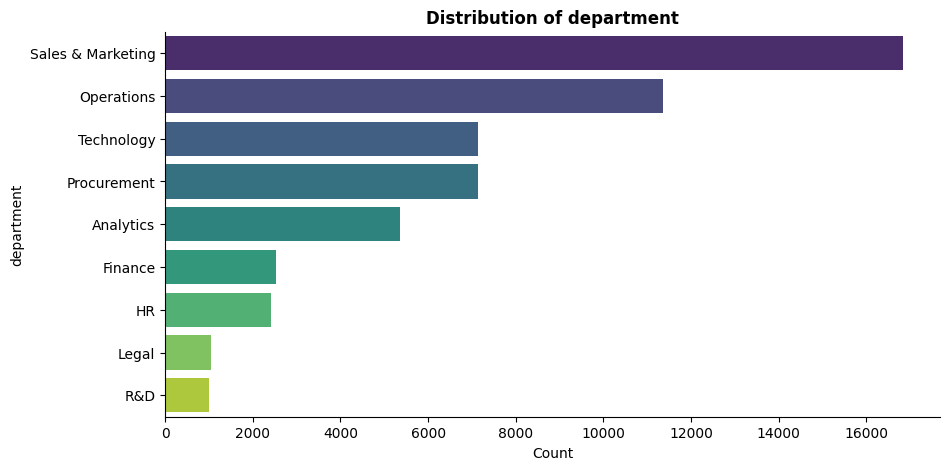

/tmp/ipykernel_2231/456599800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


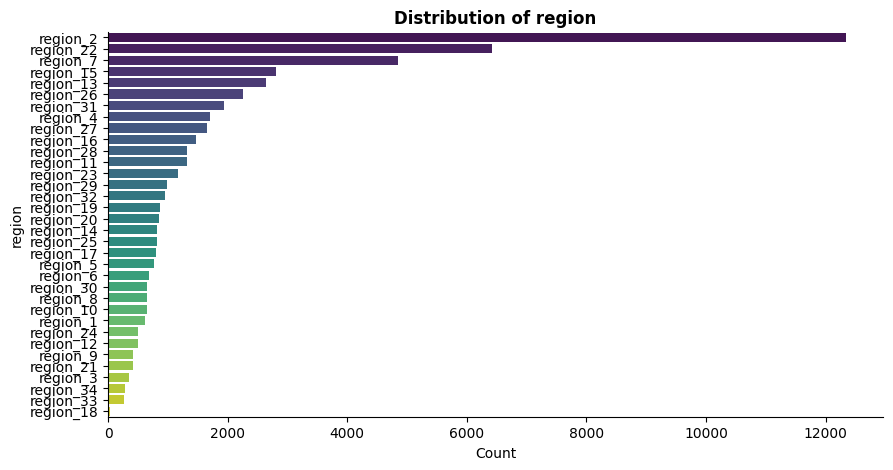

/tmp/ipykernel_2231/456599800.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


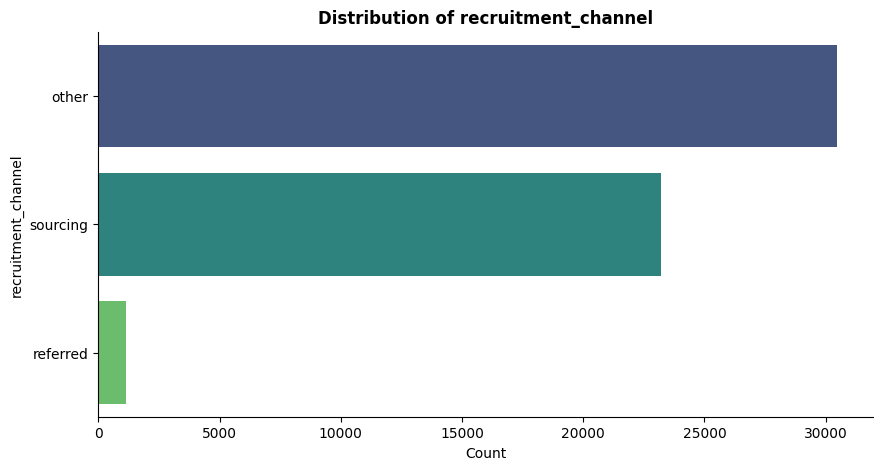

In [245]:
# Plot for categorical columns
categorical_cols_train = ['gender', 'education', 'department', 'region', 'recruitment_channel']

for col in categorical_cols_train:
    plt.figure(figsize=(10, 5))

    order = df_train[col].value_counts().index

    sns.countplot(
        data=df_train,
        y=col,
        order=order,
        palette='viridis'
    )

    plt.title(f'Distribution of {col}', fontweight='bold')
    plt.xlabel('Count')
    plt.ylabel(col)

    sns.despine() # remove top and right borders
    plt.show()

**Observation:**
- There are more male employees than female employees in the organization. However, female employees also represent a significant portion of the workforce.
- Mostly Bechlor's employees in the organisations.
- The Sales & Marketing department shows the highest employee distribution, indicating it is the largest department in the organization.
- Region 2 dominates the employee distribution, indicating it is the largest operational region in the dataset

### **Bivariate Analysis**

**Promotion rate by department**

/tmp/ipykernel_2231/281685580.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=dept_promotion, x='department', y='is_promoted', palette='viridis')


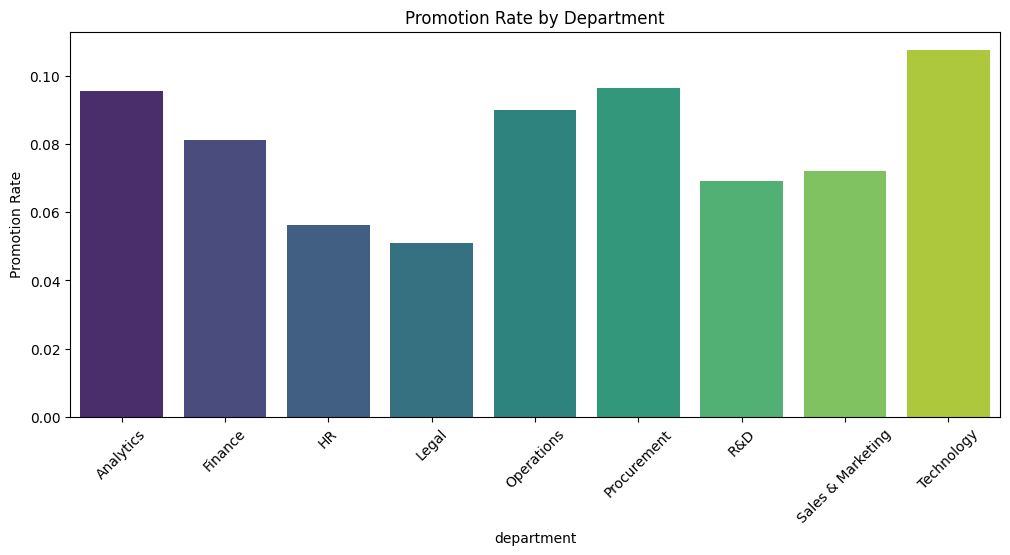

In [246]:
dept_promotion = df_train.groupby('department')['is_promoted'].mean().reset_index()

plt.figure(figsize=(12,5))
sns.barplot(data=dept_promotion, x='department', y='is_promoted', palette='viridis')
plt.title("Promotion Rate by Department")
plt.ylabel("Promotion Rate")
plt.xticks(rotation=45)
plt.show()

**Promotion Rate by Gender**

/tmp/ipykernel_2231/1812879420.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gender_promotion, x='gender', y='is_promoted', palette='viridis')


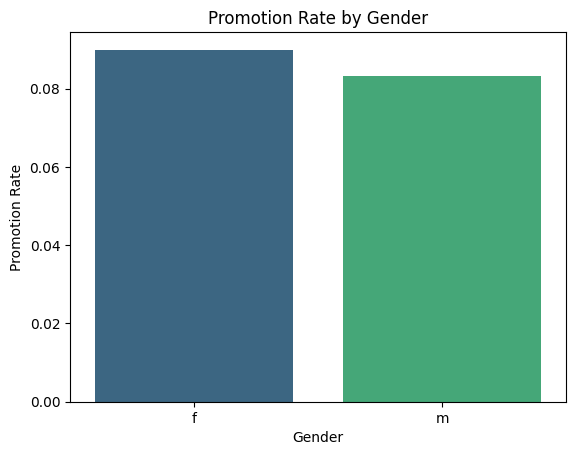

In [247]:
gender_promotion = df_train.groupby('gender')['is_promoted'].mean().reset_index()

ax = sns.barplot(data=gender_promotion, x='gender', y='is_promoted', palette='viridis')

plt.title("Promotion Rate by Gender")
plt.ylabel("Promotion Rate")
plt.xlabel("Gender")
plt.show()

**Promotion Rate by Age**

/tmp/ipykernel_2231/4285667521.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='is_promoted', y='age', palette='Set2')


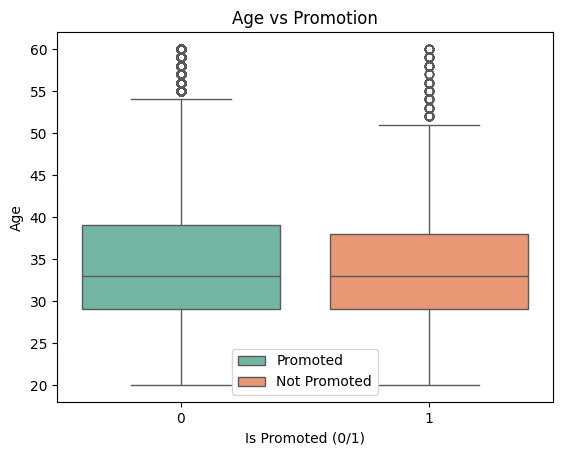

In [248]:
sns.boxplot(data=df_train, x='is_promoted', y='age', palette='Set2')
plt.title("Age vs Promotion")
plt.xlabel("Is Promoted (0/1)")
plt.ylabel("Age")
plt.legend(['Promoted', 'Not Promoted'])
plt.show()

**Promotion Rate vs Previous Year Rating**




/tmp/ipykernel_2231/4188918040.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='is_promoted', y='previous_year_rating', palette='Set2')


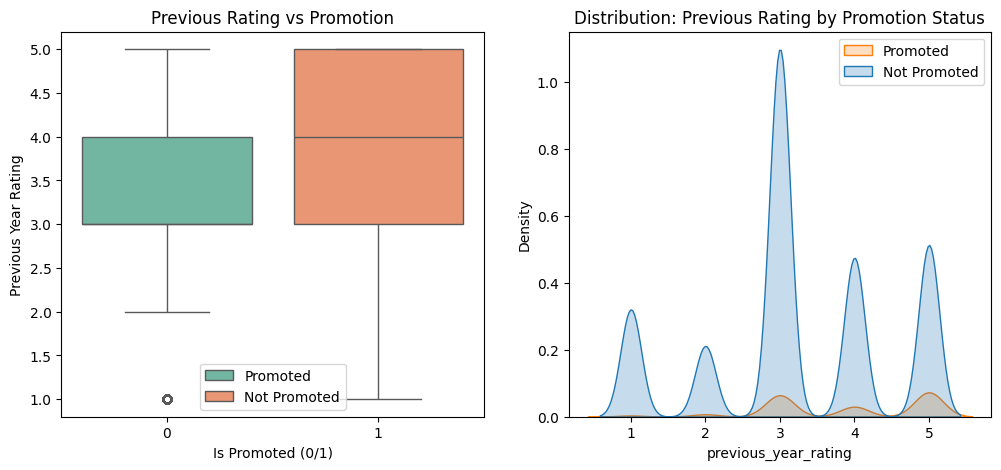

In [249]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df_train, x='is_promoted', y='previous_year_rating', palette='Set2')
plt.title("Previous Rating vs Promotion")
plt.xlabel("Is Promoted (0/1)")
plt.ylabel("Previous Year Rating")
plt.legend(['Promoted', 'Not Promoted'])

# Side-by-side distribution
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_train, x='previous_year_rating', hue='is_promoted', fill=True)
plt.title("Distribution: Previous Rating by Promotion Status")
plt.legend(['Promoted', 'Not Promoted'])
plt.show()

**Promotion Rate vs Training Score**

/tmp/ipykernel_2231/4288311097.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='is_promoted', y='avg_training_score', palette='Set2')


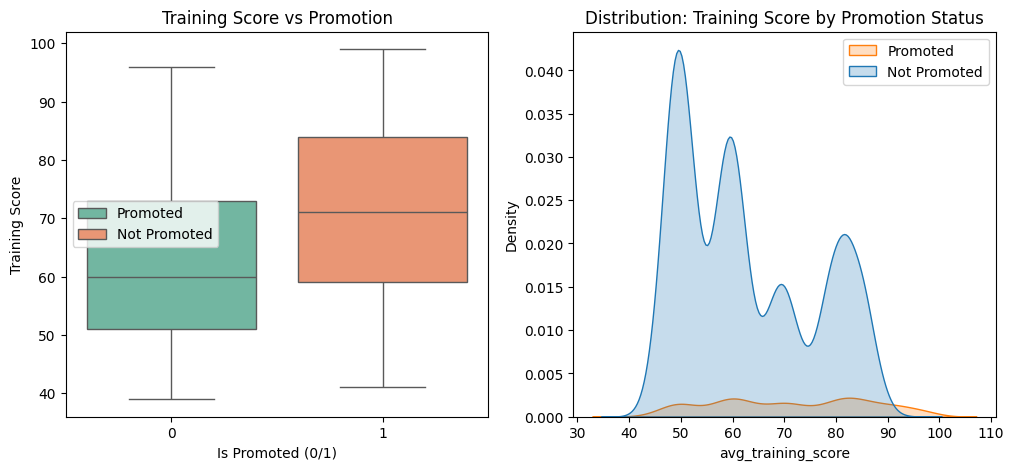

In [250]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)

sns.boxplot(data=df_train, x='is_promoted', y='avg_training_score', palette='Set2')
plt.title("Training Score vs Promotion")
plt.xlabel("Is Promoted (0/1)")
plt.ylabel("Training Score")
plt.legend(['Promoted', 'Not Promoted'])


# Distribution
plt.subplot(1, 2, 2)
sns.kdeplot(data=df_train, x='avg_training_score', hue='is_promoted', fill=True)
plt.title("Distribution: Training Score by Promotion Status")
plt.legend(['Promoted', 'Not Promoted'])
plt.show()

**Promotion Rate vs Awards**

/tmp/ipykernel_2231/4012018526.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=awards_promotion, x='awards_won?', y='is_promoted', palette='viridis')


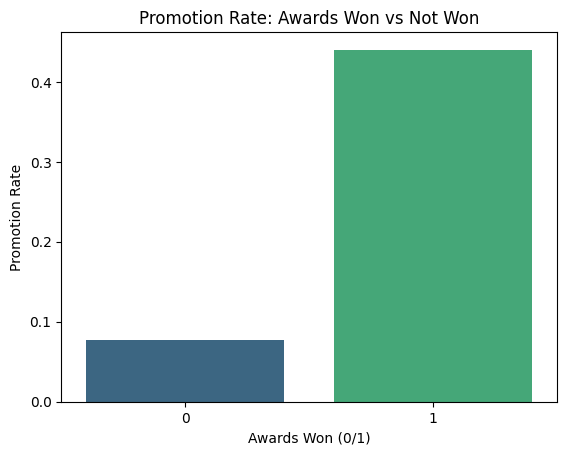

In [251]:
awards_promotion = df_train.groupby('awards_won?')['is_promoted'].mean().reset_index()

sns.barplot(data=awards_promotion, x='awards_won?', y='is_promoted', palette='viridis')
plt.title("Promotion Rate: Awards Won vs Not Won")
plt.xlabel("Awards Won (0/1)")
plt.ylabel("Promotion Rate")
plt.show()

### **Multi-variate Analysis**

**Correlation Heatmap**

In [252]:
df_train.select_dtypes(include='number').columns


Index(['employee_id', 'no_of_trainings', 'age', 'previous_year_rating',
       'length_of_service', 'awards_won?', 'avg_training_score',
       'is_promoted'],
      dtype='object')

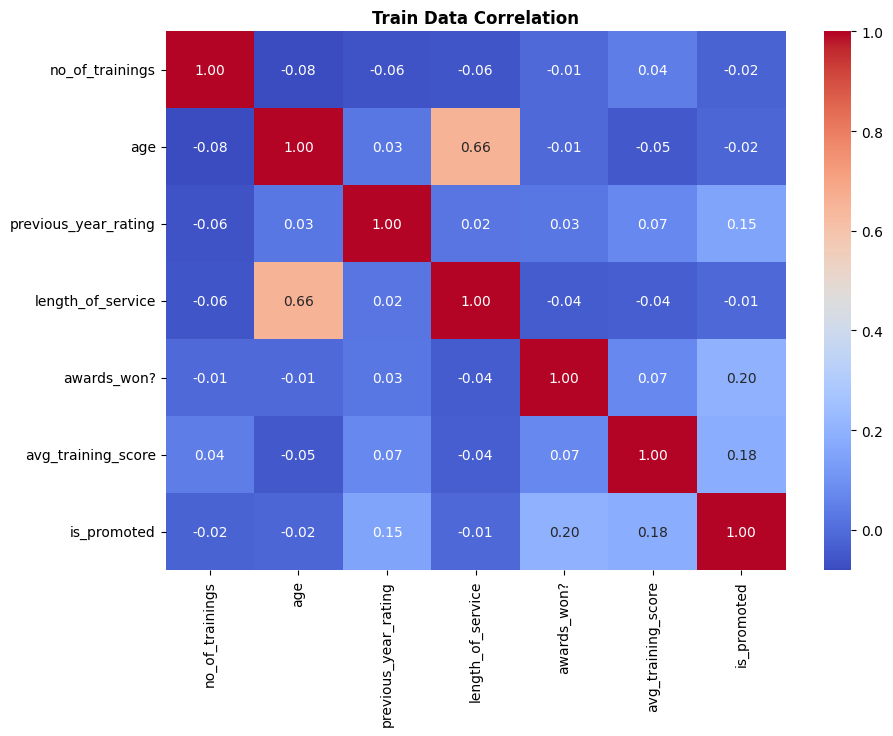

In [253]:
numerical_columns = ['no_of_trainings', 'age', 'previous_year_rating', 'length_of_service',
                     'awards_won?', 'avg_training_score', 'is_promoted']

plt.figure(figsize=(10,7))

sns.heatmap(df_train[numerical_columns].corr(),
            annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Train Data Correlation", fontweight='bold')
plt.show()

plt.show()

**Obseravtions:**
- The correlation matrix shows a similar pattern in both train and test datasets.
- In the train data correlation, the target variable (is_promoted) has a positive correlation with previous_year_rating, awards_won?, and avg_training_score.
- Additionally, age and length_of_service show a strong positive relationship, indicating that employees with higher age tend to have longer service duration.
- There is also a relationship between region and education, and gender and department, indicating some structural patterns in the workforce.

### **Chi-Square Test for Independence**

I used the Chi-Square test of independence to examine whether employee promotion (is_promoted) is associated with categorical features such as gender, department, recruitment channel, education, and awards won.

In [254]:
# Contingency table for Chi-Square test: promotion status vs gender
contingency_gender = pd.crosstab(df_train['is_promoted'], df_train['gender'])

print(contingency_gender)

gender           f      m
is_promoted              
0            14845  35295
1             1467   3201


**Observations:** Female employees show a slightly higher promotion rate (approx. 9%) compared to males (approx. 8.3%), however statistical testing is required to determine whether this difference is significant.

In [255]:
contingency_department = pd.crosstab(df_train['is_promoted'], df_train['department'])

print(contingency_department)

department   Analytics  Finance    HR  Legal  Operations  Procurement  R&D  \
is_promoted                                                                  
0                 4840     2330  2282    986       10325         6450  930   
1                  512      206   136     53        1023          688   69   

department   Sales & Marketing  Technology  
is_promoted                                 
0                        15627        6370  
1                         1213         768  


In [256]:
contingency_recruitment = pd.crosstab(df_train['is_promoted'], df_train['recruitment_channel'])

print(contingency_recruitment)

recruitment_channel  other  referred  sourcing
is_promoted                                   
0                    27890      1004     21246
1                     2556       138      1974


In [257]:
contingency_education = pd.crosstab(df_train['is_promoted'], df_train['education'])

print(contingency_education)

education    Bachelor's  Below Secondary  Master's & above  Unknown
is_promoted                                                        
0                 33661              738             13454     2287
1                  3008               67              1471      122


In [258]:
contingency_awards_won = pd.crosstab(df_train['is_promoted'], df_train['awards_won?'])

print(contingency_awards_won)

awards_won?      0    1
is_promoted            
0            49429  711
1             4109  559


In [259]:
# Function to perform Chi-Square test of independence
# Input: contingency table (cross-tabulated frequency data)
# Output: chi-square statistic, p-value, degrees of freedom, and expected frequencies
def perform_chi2_test(table):
    chi2, p, dof, expected = chi2_contingency(table)
    return chi2, p, dof, expected

In [260]:
# Applying Chi-Square test to multiple categorical features
results = {}
results['recruitment_channel'] = perform_chi2_test(contingency_recruitment)
results['gender'] = perform_chi2_test(contingency_gender)
results['education'] = perform_chi2_test(contingency_education)
results['department'] = perform_chi2_test(contingency_department)
results['awards_won'] = perform_chi2_test(contingency_awards_won)

In [261]:
# Output results
for var, (chi2, p, dof, expected) in results.items():
    print(f"{var}")
    print(f"Chi-square: {chi2:.2f}")
    print(f"P-value: {p:.4f}")

    if p < 0.05:
        print("Result: Significant association with promotion\n")
    else:
        print("Result: No significant association with promotion\n")

recruitment_channel
Chi-square: 19.24
P-value: 0.0001
Result: Significant association with promotion

gender
Chi-square: 6.68
P-value: 0.0098
Result: Significant association with promotion

education
Chi-square: 75.87
P-value: 0.0000
Result: Significant association with promotion

department
Chi-square: 151.43
P-value: 0.0000
Result: Significant association with promotion

awards_won
Chi-square: 2098.07
P-value: 0.0000
Result: Significant association with promotion



**Observations:** Chi-Square tests revealed a statistically significant association between promotion status (is_promoted) and all examined categorical variables, including awards_won, gender, recruitment_channel, education, and department (p < 0.05). This suggests that these factors are not independent of promotion outcomes.

### **Key Findings:**

1. The training and testing datasets contain the same set of variables and exhibit similar distributions across key features, indicating that the testing dataset is representative of the training dataset.
2. The dataset was provided with predefined training and testing subsets, with approximately 70% of the observations in the training dataset and 30% in the testing dataset.
3. Descriptive statistics show that both datasets have comparable average values for important numerical features, including age, previous_year_rating, length_of_service, awards_won?, and avg_training_score.
4. The target variable, is_promoted, is imbalanced, with only 8.52% of employees receiving promotions, while the majority (91.48%) were not promoted.
5. Missing values were identified in:

- education: 2,409 missing values in the training dataset and 1,034 in the testing dataset.
- previous_year_rating: 4,124 missing values in the training dataset and 1,812 in the testing dataset.

To address these missing values:

- Missing values in education were imputed with "Unknown".
- Missing values in previous_year_rating were imputed with mode.
6. Correlation analysis revealed no evidence of multicollinearity among the numerical variables, suggesting that the features provide distinct information.
7. The Chi-Square Test of Independence identified statistically significant associations between promotion status (is_promoted) and the categorical variables awards_won, gender, recruitment_channel, education, and department (p < 0.05). This indicates that promotion outcomes are related to these categorical factors.

Overall, previous_year_rating, avg_training_score, awards_won, department, and education emerged as important factors associated with employee promotions and may serve as valuable predictors in predictive modeling.

**Ready for Model Building:**
After completing data cleaning, exploratory data analysis, and statistical testing, the dataset is now fully prepared for predictive modeling. All missing values have been appropriately handled, feature distributions have been analyzed, and key relationships with the target variable have been identified. The data is now suitable for building machine learning models to predict employee promotions effectively.